In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('hotel_bookings_cleaned.csv')
display(df.head())

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,C,3,No Deposit,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,C,4,No Deposit,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,C,0,No Deposit,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,A,0,No Deposit,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,A,0,No Deposit,0,Transient,98.0,0,1,Check-Out,2015-07-03


# Data Analytics 
1. find cancellation rate of hotel 

is_canceled
0    0.629205
1    0.370795
Name: proportion, dtype: float64


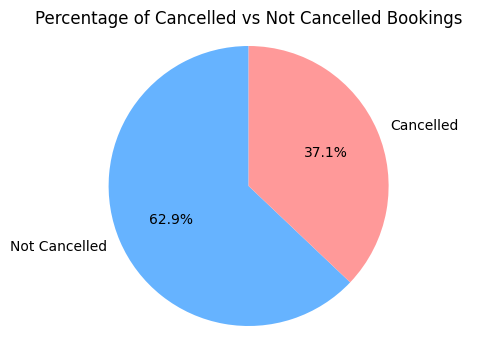

In [5]:
# cancell and not cancelled percwntage 
cancelled_percentage = df['is_canceled'].value_counts(normalize=True)
print(cancelled_percentage)
# Plotting the percentage of cancelled and not cancelled bookings(pie chart)
plt.figure(figsize=(6, 4))
plt.pie(cancelled_percentage, labels=['Not Cancelled', 'Cancelled'], autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999'])
plt.title('Percentage of Cancelled vs Not Cancelled Bookings')
plt.axis('equal')  # Equal aspect ratio ensures that pie chart is circular
plt.show()


# insight for above data 👆
Although the majority of bookings (63%) are not cancelled, a 37% cancellation rate indicates a substantial revenue risk. The hotel may need to review cancellation policies, advance payment strategies, or analyze seasonal cancellation patterns.

2. cancel and not cancel ratio base on hotel type

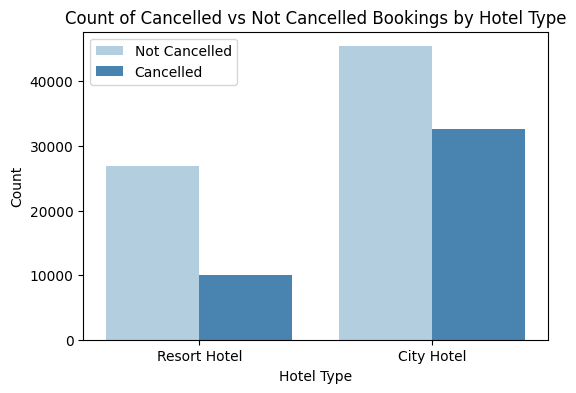

In [7]:
# count plot for cancelled and not cancelled bookings
plt.figure(figsize=(6, 4))
ax1 = sns.countplot(x = "hotel" , hue = "is_canceled", data = df, palette = "Blues")
legend_labels, _ = ax1.get_legend_handles_labels()
plt.title('Count of Cancelled vs Not Cancelled Bookings by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Count')
plt.legend(legend_labels, ['Not Cancelled', 'Cancelled'])
plt.show()

In [ ]:
resort_hotel = df[df["hotel"] == "Resort Hotel"]
resort_hotel["is_canceled"].value_counts(normalize=True)

is_canceled
0    0.727997
1    0.272003
Name: proportion, dtype: float64

In [12]:
city_hotel = df[df["hotel"] == "City Hotel"]
city_hotel["is_canceled"].value_counts(normalize=True)

is_canceled
0    0.582297
1    0.417703
Name: proportion, dtype: float64

# insight for above data 👆
City Hotels have a significantly higher cancellation rate (41.8%) compared to Resort Hotels (27.2%).
This means bookings in City Hotels are approximately 15% more likely to be cancelled than in Resort Hotels.

3. price affect on hotel cancellation 

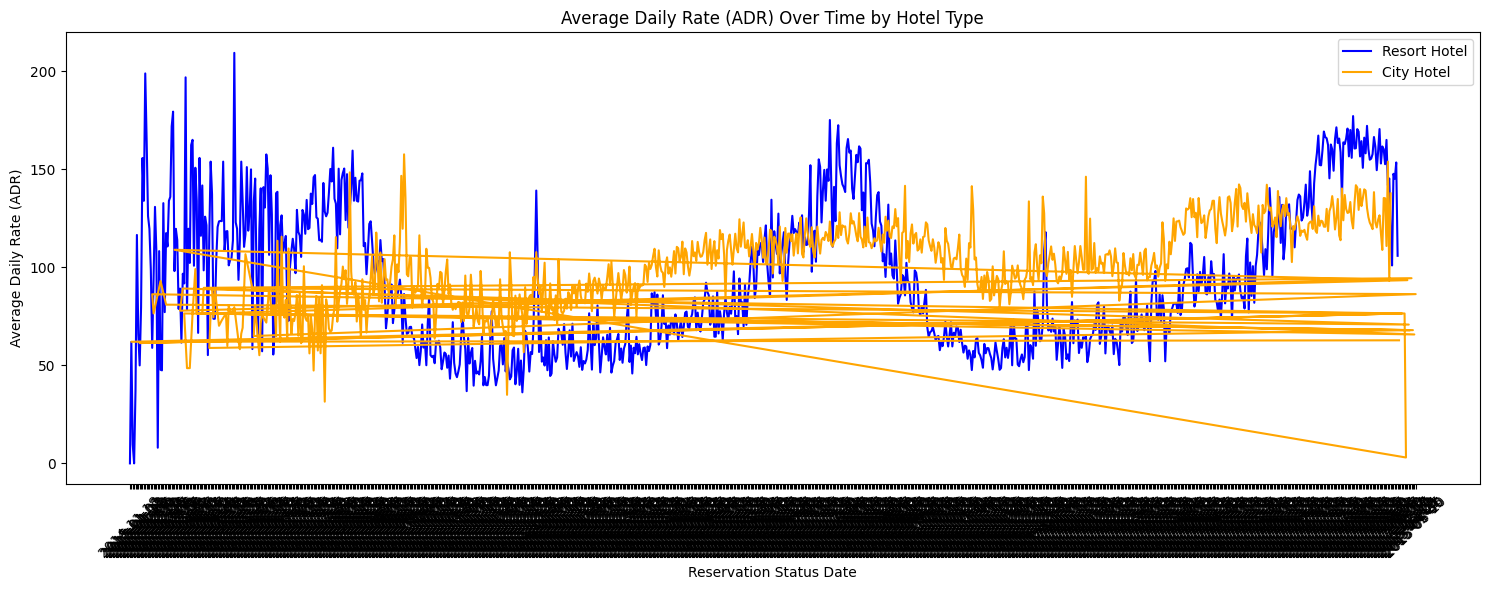

In [62]:
resort_hotel = resort_hotel.groupby("reservation_status_date")[["adr"]].mean().reset_index()
city_hotel = city_hotel.groupby("reservation_status_date")[["adr"]].mean().reset_index()

# line plot for average daily rate (adr) over time for both hotel types
plt.figure(figsize=(15, 6))
plt.plot(resort_hotel["reservation_status_date"], resort_hotel["adr"], label="Resort Hotel", color='blue')
plt.plot(city_hotel["reservation_status_date"], city_hotel["adr"], label="City Hotel", color='orange')
plt.title("Average Daily Rate (ADR) Over Time by Hotel Type")       
plt.xlabel("Reservation Status Date")
plt.ylabel("Average Daily Rate (ADR)")
plt.legend()    
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

4. month wise cancell or not cancelled 

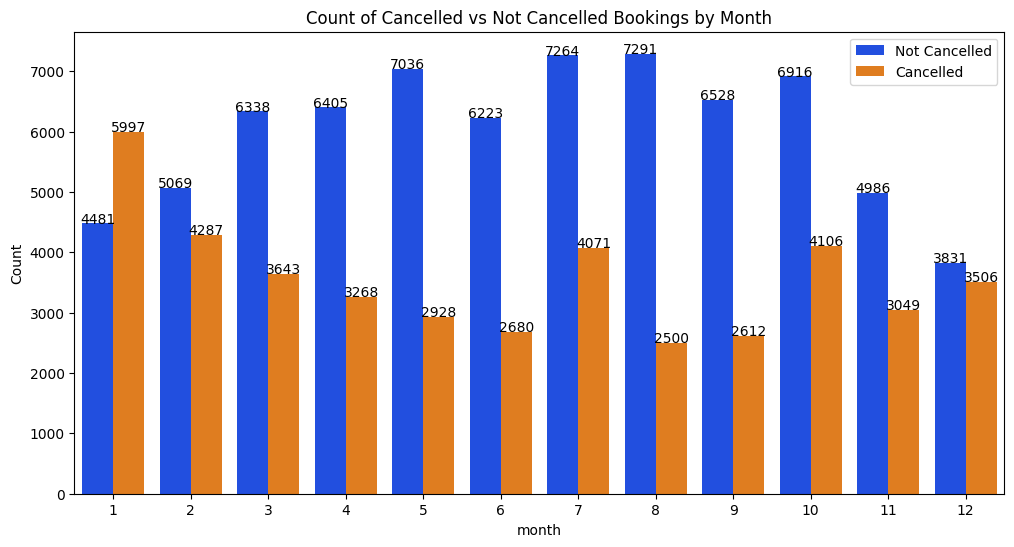

In [ ]:
df["month"] = df["reservation_status_date"].dt.month
plt.figure(figsize=(12, 6))
ax1 = sns.countplot(x="month", hue="is_canceled", data=df, palette="bright")
# add data labels on top of the bars
for p in ax1.patches:
    height = p.get_height()
    if height > 0:  # Only add labels for bars with height greater than 0
        ax1.text(p.get_x() + p.get_width() / 2., height + 5, int(height), ha="center")
legend_labels, _ = ax1.get_legend_handles_labels()
plt.title("Count of Cancelled vs Not Cancelled Bookings by Month")
plt.xlabel("month")
plt.ylabel("Count")
plt.legend(legend_labels, ['Not Cancelled', 'Cancelled'])
plt.show()

# insight for above data 👆
January experiences the highest cancellation volume, indicating potential booking uncertainty at the beginning of the year. In contrast, August shows the lowest cancellations and the highest confirmed reservations, suggesting strong seasonal demand and more committed travelers.

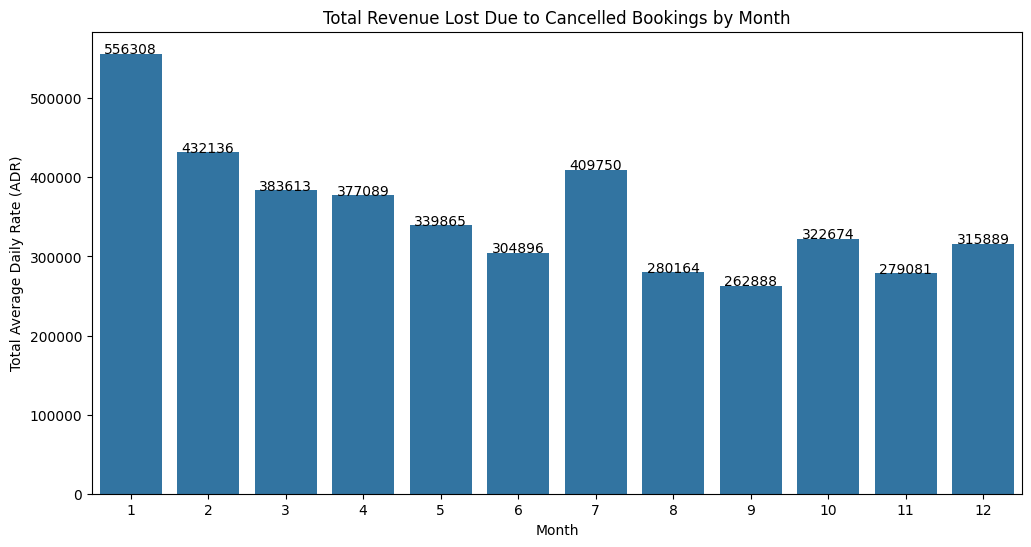

In [66]:
# ADR by month 
adr_by_month = df[df['is_canceled'] == 1].groupby("month")["adr"].sum().reset_index()
plt.figure(figsize=(12, 6))
ax = sns.barplot(x="month", y="adr", data=adr_by_month)

# add data labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Only add labels for bars with height greater than 0
        ax.text(p.get_x() + p.get_width() / 2., height + 5, int(height), ha="center")
        
plt.title("Total Revenue Lost Due to Cancelled Bookings by Month")
plt.xlabel("Month")
plt.ylabel("Total Average Daily Rate (ADR)")
plt.show()

5. cancelled hotel base on city

country
PRT    26964
GBR     2324
ESP     1917
FRA     1844
ITA     1289
DEU     1189
BRA      811
IRL      806
BEL      458
USA      458
Name: count, dtype: int64


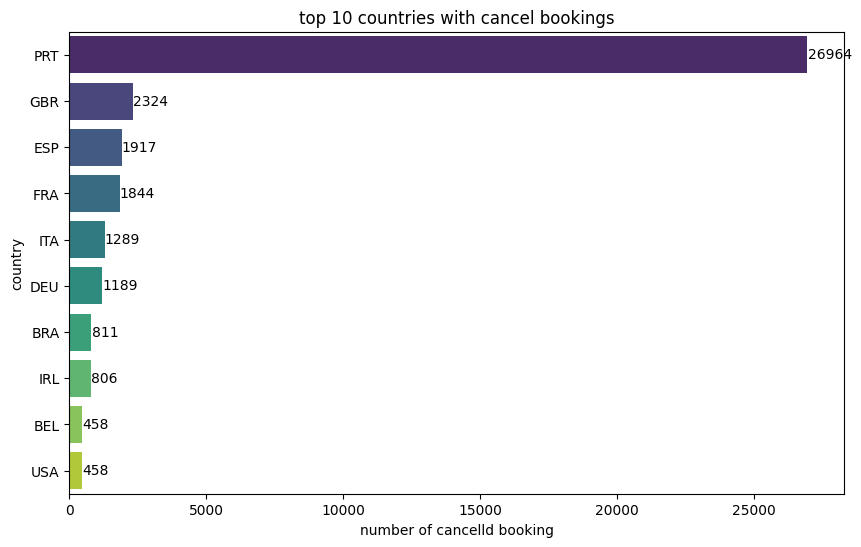

In [67]:
filter_on_cancelled = df[df["is_canceled"] == 1]
top_10_city = filter_on_cancelled["country"].value_counts().head(10)
print(top_10_city)

# horizontal bar plot for top 10 countries with most cancelled bookings
plt.figure(figsize=(10,6))
ax = sns.barplot(x = top_10_city.values , y = top_10_city.index ,
             palette = "viridis",hue=top_10_city.index)
plt.title("top 10 countries with cancel bookings")
plt.xlabel("number of cancelld booking")
plt.ylabel("country")

# Add data labels
for i in ax.patches:
    ax.text(
        i.get_width() + 5,          # position (slightly right of bar)
        i.get_y() + i.get_height()/2,
        int(i.get_width()),         # value
        va='center'
    )
plt.show()

# insigh for above data 👆
Portugal (PRT) accounts for the highest number of cancelled bookings by a significant margin. This is likely due to a higher volume of domestic bookings compared to international markets. Among international travelers, the United Kingdom (GBR), Spain (ESP), and France (FRA) contribute the next highest cancellation volumes.

6. market segment analysis

In [ ]:
# customer count of each market segment
print(df.market_segment.value_counts())
print(df.market_segment.value_counts(normalize=True))


market_segment
Online TA        53638
Offline TA/TO    24052
Groups           19709
Direct           11541
Corporate         5104
Complementary      734
Aviation           237
Name: count, dtype: int64
market_segment
Online TA        0.466357
Offline TA/TO    0.209121
Groups           0.171360
Direct           0.100343
Corporate        0.044377
Complementary    0.006382
Aviation         0.002061
Name: proportion, dtype: float64


# insigh for above data 👆
The hotel relies heavily on Online Travel Agencies (46.6%) for customer acquisition, indicating strong digital channel dependence. Offline agents and group bookings also play a significant role, while direct bookings remain relatively low at 10%.

7. which ADR high (cancel or not cancel booking)

  reservation_status_date         adr
0              2014-10-17   62.800000
1              2014-11-18    0.000000
2              2015-01-01   62.062779
3              2015-01-02    9.633750
4              2015-01-18    0.000000
5              2015-01-20   76.500000
6              2015-01-21   37.301209
7              2015-01-22  116.568333
8              2015-01-29   66.000000
9              2015-01-30   56.805970
  reservation_status_date         adr
0              2015-07-01   31.650000
1              2015-07-02   95.924000
2              2015-07-03   97.645205
3              2015-07-04  110.480000
4              2015-07-05  100.308485
5              2015-07-06   91.540000
6              2015-07-07   89.785000
7              2015-07-08   80.219600
8              2015-07-09   87.349444
9              2015-07-10   86.710741


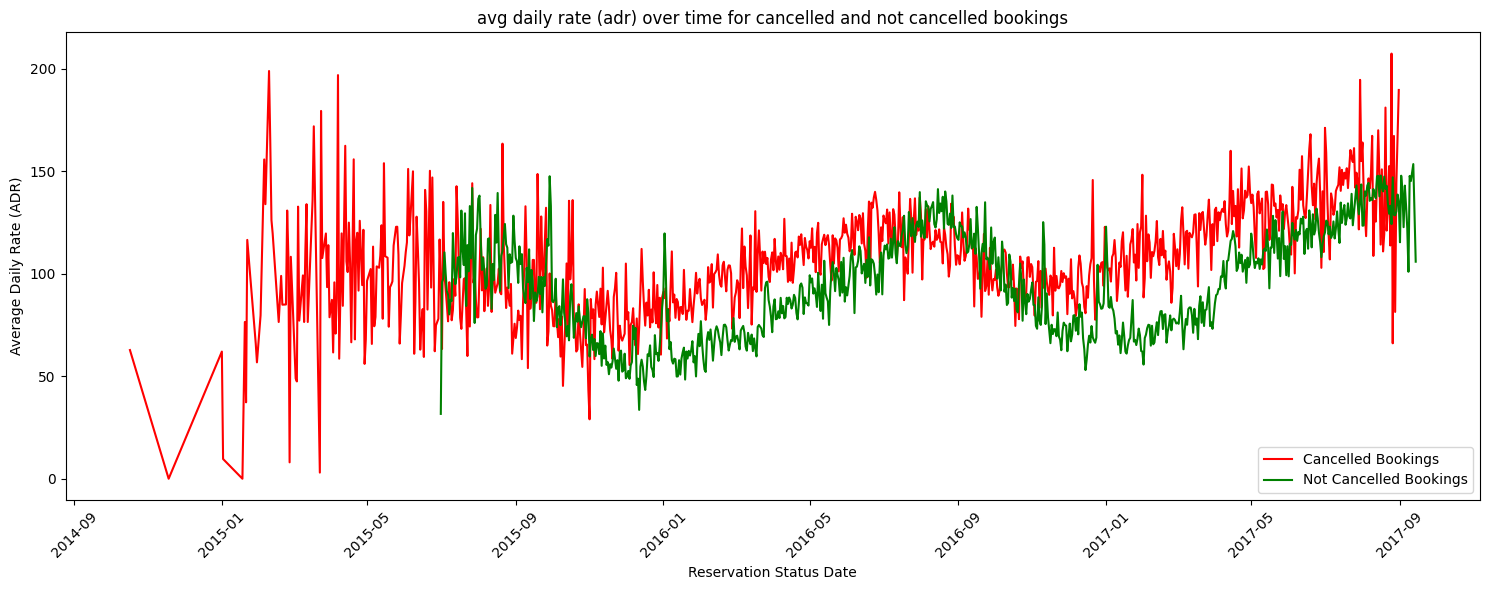

In [87]:
cancel_adr = df[df["is_canceled"] == 1].groupby("reservation_status_date")["adr"].mean().reset_index()
cancel_adr.sort_values("reservation_status_date", inplace=True)
print(cancel_adr.head(10))

not_cancel_adr = df[df["is_canceled"] == 0].groupby("reservation_status_date")["adr"].mean().reset_index()
not_cancel_adr.sort_values("reservation_status_date", inplace=True)
print(not_cancel_adr.head(10))

plt.figure(figsize=(15, 6))
plt.title("avg daily rate (adr) over time for cancelled and not cancelled bookings")
plt.plot(cancel_adr['reservation_status_date'], cancel_adr['adr'] , label='Cancelled Bookings', color='red')
plt.plot(not_cancel_adr['reservation_status_date'], not_cancel_adr['adr'] , label='Not Cancelled Bookings', color='green')
plt.xlabel("Reservation Status Date")
plt.ylabel("Average Daily Rate (ADR)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# insigh for above data 👆
The ADR trend over time indicates that cancelled bookings often have comparable or slightly higher average rates than non-cancelled bookings. This suggests that higher-priced reservations are not necessarily more secure and may be more prone to cancellation. Additionally, cancelled bookings display greater volatility in pricing, indicating variability in booking behavior and potential revenue risk during peak seasons.